In [1]:

# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings("ignore")
# Download NLTK stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kelly\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
# Load the Dataset (.txt file)
data = pd.read_csv(r"C:\Users\kelly\Downloads\archive\train.txt", sep=';', names=['Text', 'Emotion'])

data.head()


,Text,Emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


Dataset Shape: (16000, 2)

Unique Emotions: ['sadness' 'anger' 'love' 'surprise' 'fear' 'joy']

Emotion Counts:
 Emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


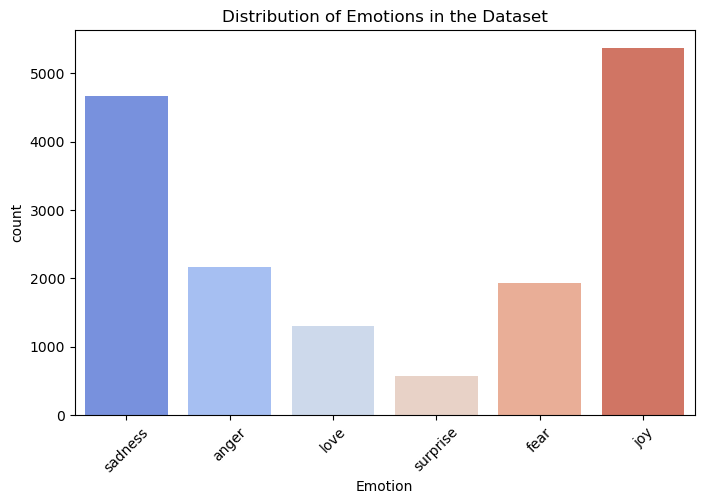

In [3]:
# Explore the Data

print("Dataset Shape:", data.shape)
print("\nUnique Emotions:", data['Emotion'].unique())
print("\nEmotion Counts:\n", data['Emotion'].value_counts())

# Visualize distribution
plt.figure(figsize=(8,5))
sns.countplot(x='Emotion', data=data, palette='coolwarm')
plt.title("Distribution of Emotions in the Dataset")
plt.xticks(rotation=45)
plt.show()


In [4]:
# Text Cleaning Function
def clean_text(text):
    text = text.lower()  # Lowercase
    text = re.sub(r"http\S+|www\S+", "", text)  # Remove URLs
    text = re.sub(r"[^a-zA-Z]", " ", text)  # Keep letters only
    text = re.sub(r"\s+", " ", text)  # Remove extra spaces
    text = ' '.join(word for word in text.split() if word not in stop_words)  # Remove stopwords
    return text

data['clean_text'] = data['Text'].apply(clean_text)
data.head()


,Text,Emotion,clean_text
0,i didnt feel humiliated,sadness,didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,sadness,go feeling hopeless damned hopeful around some...
2,im grabbing a minute to post i feel greedy wrong,anger,im grabbing minute post feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,love,ever feeling nostalgic fireplace know still pr...
4,i am feeling grouchy,anger,feeling grouchy


In [5]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import string

# Download needed NLTK data
nltk.download('wordnet')
nltk.download('stopwords')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation
    text = ''.join([c for c in text if c not in string.punctuation])
    # Tokenize and lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# Apply to your dataset
data['Clean_Text'] = data['Text'].apply(preprocess_text)

# Show sample
data[['Text', 'Clean_Text']].head()


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\kelly\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kelly\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Text,Clean_Text
0,i didnt feel humiliated,didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,go feeling hopeless damned hopeful around some...
2,im grabbing a minute to post i feel greedy wrong,im grabbing minute post feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,ever feeling nostalgic fireplace know still pr...
4,i am feeling grouchy,feeling grouchy


In [6]:
X = data['Clean_Text']  # Use the cleaned text column
y = data['Emotion']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 12800
Testing samples: 3200


In [7]:
#  TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Vectorized Training Shape:", X_train_vec.shape)


Vectorized Training Shape: (12800, 5000)


In [8]:
# Model Training
model = LogisticRegression(max_iter=300)
model.fit(X_train_vec, y_train)

# Predictions
y_pred = model.predict(X_test_vec)


✅ Accuracy: 86.91 %

Classification Report:
               precision    recall  f1-score   support

       anger       0.91      0.80      0.85       432
        fear       0.88      0.82      0.85       387
         joy       0.83      0.95      0.89      1072
        love       0.86      0.64      0.73       261
     sadness       0.90      0.93      0.92       933
    surprise       0.87      0.59      0.70       115

    accuracy                           0.87      3200
   macro avg       0.87      0.79      0.82      3200
weighted avg       0.87      0.87      0.87      3200



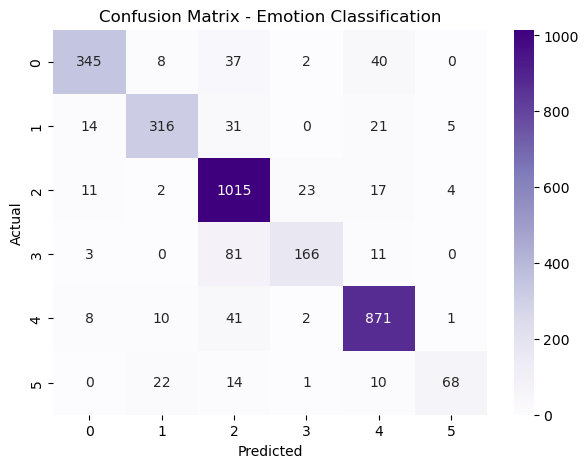

In [9]:

#  Model Evaluation

print("✅ Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2), "%\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix - Emotion Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [10]:
# Test with Custom Text
sample_text = ["I feel so lonely and tired lately.", "I am really happy with my progress."]
sample_clean = [clean_text(t) for t in sample_text]
sample_vec = vectorizer.transform(sample_clean)

predictions = model.predict(sample_vec)
for text, emotion in zip(sample_text, predictions):
    print(f"Text: {text} → Predicted Emotion: {emotion}")


Text: I feel so lonely and tired lately. → Predicted Emotion: sadness
Text: I am really happy with my progress. → Predicted Emotion: joy


In [11]:
# Save Model and Vectorizer

import joblib

joblib.dump(model, "emotion_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("✅ Model and vectorizer saved successfully!")


✅ Model and vectorizer saved successfully!


In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on test data
X_test_tfidf = vectorizer.transform(X_test)
y_pred = model.predict(X_test_tfidf)

# Evaluate
print("✅ Model Accuracy:", accuracy_score(y_test, y_pred))
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))


✅ Model Accuracy: 0.8690625

📊 Classification Report:
               precision    recall  f1-score   support

       anger       0.91      0.80      0.85       432
        fear       0.88      0.82      0.85       387
         joy       0.83      0.95      0.89      1072
        love       0.86      0.64      0.73       261
     sadness       0.90      0.93      0.92       933
    surprise       0.87      0.59      0.70       115

    accuracy                           0.87      3200
   macro avg       0.87      0.79      0.82      3200
weighted avg       0.87      0.87      0.87      3200



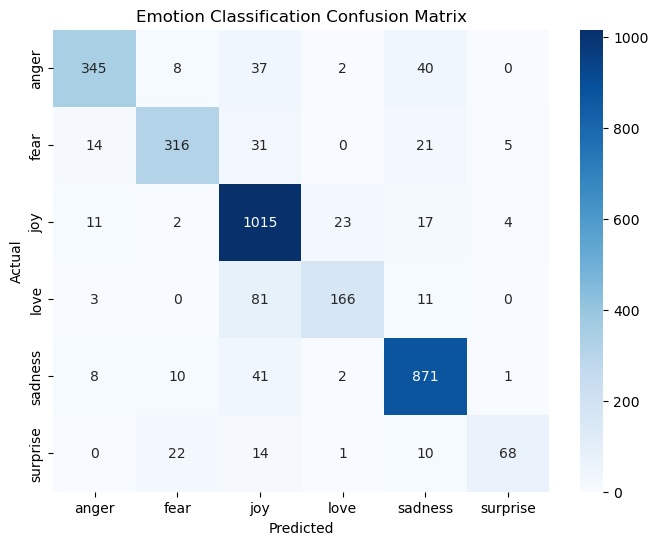

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Emotion Classification Confusion Matrix')
plt.show()


In [14]:
samples = [
    "I'm bored.",
    "I feel amazing today!",
    "I'm really anxious about my exams.",
    "I'm frustrated with everything.",
    "I'm so happy and grateful."
]

for text in samples:
    cleaned = preprocess_text(text)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    print(f"Text: {text} → Predicted Emotion: {pred}")


Text: I'm bored. → Predicted Emotion: joy
Text: I feel amazing today! → Predicted Emotion: joy
Text: I'm really anxious about my exams. → Predicted Emotion: fear
Text: I'm frustrated with everything. → Predicted Emotion: anger
Text: I'm so happy and grateful. → Predicted Emotion: joy


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Save metrics
metrics = {
    "accuracy": 0.869,
    "precision": 0.87,
    "recall": 0.79,
    "f1": 0.82
}
pd.DataFrame([metrics]).to_csv("model_metrics.csv", index=False)

# Save emotion distribution
emotion_counts = data['Emotion'].value_counts()
emotion_counts.to_csv("emotion_distribution.csv")

# Save a chart
plt.figure(figsize=(6,4))
emotion_counts.plot(kind="bar", color="skyblue")
plt.title("Emotion Distribution in Training Data")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("emotion_distribution.png")
plt.close()
